In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully!")
display(df.head())

Titanic dataset loaded successfully!


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare"]

df_model = df[features + ["survived"]].copy()

print("Features selected successfully!")
display(df_model.head())

Features selected successfully!


,pclass,sex,age,sibsp,parch,fare,survived
0,3,male,22.0,1,0,7.2500,0
1,1,female,38.0,1,0,71.2833,1
2,3,female,26.0,0,0,7.9250,1
3,1,female,35.0,1,0,53.1000,1
4,3,male,35.0,0,0,8.0500,0


In [4]:
df_model["age"] = df_model["age"].fillna(df_model["age"].median())

df_model = df_model.dropna()

print("Missing values handled successfully!")
print(df_model.isnull().sum())

Missing values handled successfully!
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
survived    0
dtype: int64


In [5]:
df_model["sex"] = df_model["sex"].map({
    "male": 0,
    "female": 1
})

print("Gender converted successfully!")
display(df_model.head())

Gender converted successfully!


,pclass,sex,age,sibsp,parch,fare,survived
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,1
3,1,1,35.0,1,0,53.1000,1
4,3,0,35.0,0,0,8.0500,0


In [6]:
X = df_model[features]
y = df_model["survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 6)
Target shape: (891,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train/Test split completed!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Train/Test split completed!
Training data: (712, 6)
Testing data: (179, 6)


In [8]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [9]:
y_pred = model.predict(X_test)

print("Predictions completed!")
display(y_pred[:10])

Predictions completed!


array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 79.89 %


In [11]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[92 13]
 [23 51]]


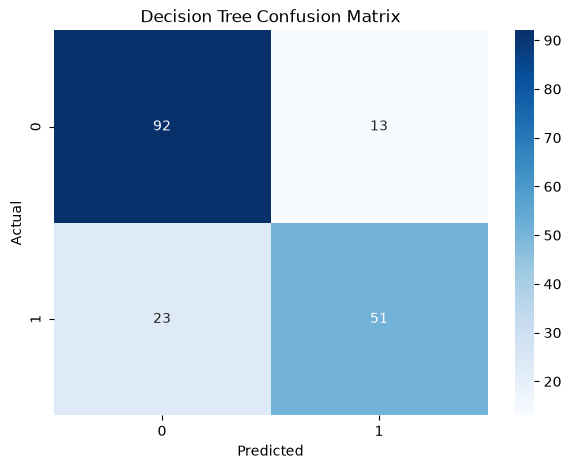

In [12]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", round(mse, 4))

Mean Squared Error: 0.2011


In [14]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Feature,Importance
1,sex,0.580531
0,pclass,0.200817
5,fare,0.093523
2,age,0.076532
3,sibsp,0.046132
4,parch,0.002466


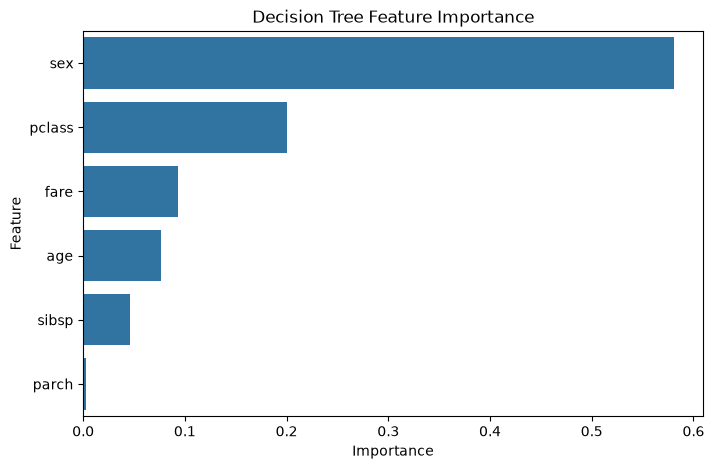

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [16]:
print("===== FINAL MODEL EVALUATION =====")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Mean Squared Error:", round(mse, 4))
print("\nConfusion Matrix:")
print(cm)

===== FINAL MODEL EVALUATION =====
Accuracy: 79.89 %
Mean Squared Error: 0.2011

Confusion Matrix:
[[92 13]
 [23 51]]
